In [1]:
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras.backend as K
from tensorflow import keras

from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda

import glob
import os
from tqdm import tqdm

import random

2025-12-01 09:01:17.982861: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# REQUIREMENT: Do not add code from Tasks 2 or 4
# REQUIREMENT: All dataset prep (crop/pad/patch/directory structure) must be finalize before attempting this task.
patch_size = 256
train_images_dir = '/home/y2b/datasets/train_images/train'
train_masks_dir = '/home/y2b/datasets/train_masks/train'
val_images_dir = '/home/y2b/datasets/val_images/val'
val_masks_dir = '/home/y2b/datasets/val_masks/val'

In [3]:
def f1(y_true, y_pred):
    def recall_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = TP / (Positives+K.epsilon())
        return recall
    
    def precision_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Pred_Positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = TP / (Pred_Positives+K.epsilon())
        return precision
    
    precision, recall = precision_m(y_true, y_pred), recall_m(y_true, y_pred)
    
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [ ]:
def combined_loss_multiclass(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')

    bce = K.binary_crossentropy(y_true, y_pred)
    dice = multiclass_dice_loss(y_true, y_pred)  # Equal weights [1,1,1]

    return 0.5 * K.mean(bce) + 0.5 * dice

def multiclass_dice_loss(y_true, y_pred, smooth=1):
    y_true = K.cast(y_true, 'float32')

    dice_losses = []
    for class_idx in range(3):
        y_true_class = y_true[..., class_idx]
        y_pred_class = y_pred[..., class_idx]

        y_true_f = K.flatten(y_true_class)
        y_pred_f = K.flatten(y_pred_class)

        intersection = K.sum(y_true_f * y_pred_f)
        dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
        dice_losses.append(1 - dice)

    return K.mean(K.stack(dice_losses))

In [5]:
from keras.layers import BatchNormalization

def improved_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    
    # Encoder - DOUBLED filters + BatchNorm
    # Block 1
    c1 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    # Block 2
    c2 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    
    # Block 3
    c3 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    c3 = BatchNormalization()(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    
    # Block 4
    c4 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    c4 = BatchNormalization()(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)
    
    # Bottleneck
    c5 = Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = BatchNormalization()(c5)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    c5 = BatchNormalization()(c5)
    
    # Decoder with BatchNorm
    u6 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = BatchNormalization()(c6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
    c6 = BatchNormalization()(c6)
    
    u7 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = BatchNormalization()(c7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
    c7 = BatchNormalization()(c7)
    
    u8 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = BatchNormalization()(c8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
    c8 = BatchNormalization()(c8)
    
    u9 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = BatchNormalization()(c9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
    c9 = BatchNormalization()(c9)
    
    outputs = Conv2D(3, (1, 1), activation='sigmoid')(c9)
    
    model = Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss=combined_loss_multiclass, metrics=['accuracy', f1])
    model.summary()
    
    return model

In [6]:
# Build U-Net
# REQUIREMENT: Model summary must be visible
model = improved_unet_model(patch_size, patch_size, 3)

2025-12-01 09:01:19.848480: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2025-12-01 09:01:19.848541: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1636] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 45857 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:61:00.0, compute capability: 8.9


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 32)         896       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 32)         128       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 dropout (Dropout)           (None, 256, 256, 32)         0         ['batch_normalization[0][0

In [7]:
# EarlyStopping()
from keras.callbacks import EarlyStopping
cb = EarlyStopping(patience=5,
                   monitor='val_loss')

In [8]:
class DataGenerator(keras.utils.Sequence):
    """Keras data generator with intelligent patch selection"""
    
    def __init__(self, image_files, mask_path, batch_size=32, patch_size=256, shuffle=True, augment=False, plant_bias=0.8):
        self.image_files = image_files
        self.mask_path = mask_path
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.shuffle = shuffle
        self.augment = augment
        self.plant_bias = plant_bias  # Probability of selecting a plant patch
        
        # Analyze patches for plant content
        print("Analyzing patches for plant content...")
        self.plant_indices = []
        self.background_indices = []
        
        for idx, img_file in enumerate(tqdm(image_files)):
            filename = os.path.basename(img_file)
            base_name = filename.replace('.png', '')
            
            # Check all three masks
            root_mask_file = os.path.join(mask_path, f"{base_name}_root.png")
            seed_mask_file = os.path.join(mask_path, f"{base_name}_seed.png")
            shoot_mask_file = os.path.join(mask_path, f"{base_name}_shoot.png")
            
            root_mask = cv2.imread(root_mask_file, cv2.IMREAD_GRAYSCALE)
            seed_mask = cv2.imread(seed_mask_file, cv2.IMREAD_GRAYSCALE)
            shoot_mask = cv2.imread(shoot_mask_file, cv2.IMREAD_GRAYSCALE)
            
            # Check if patch contains any plant pixels
            has_plant = (root_mask is not None and root_mask.sum() > 0) or \
                       (seed_mask is not None and seed_mask.sum() > 0) or \
                       (shoot_mask is not None and shoot_mask.sum() > 0)
            
            if has_plant:
                self.plant_indices.append(idx)
            else:
                self.background_indices.append(idx)
        
        print(f"Found {len(self.plant_indices)} patches with plants ({len(self.plant_indices)/len(image_files)*100:.1f}%)")
        print(f"Found {len(self.background_indices)} background patches ({len(self.background_indices)/len(image_files)*100:.1f}%)")
        
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.image_files) / self.batch_size))
    
    def __getitem__(self, index):
        # Build batch with plant_bias% plant patches and (1-plant_bias)% background patches
        n_plant = int(self.batch_size * self.plant_bias)
        n_background = self.batch_size - n_plant
        
        batch_indexes = []
        
        # Sample plant patches (with replacement if needed)
        if len(self.plant_indices) > 0 and n_plant > 0:
            plant_batch = np.random.choice(
                self.plant_indices, 
                size=min(n_plant, len(self.plant_indices)), 
                replace=len(self.plant_indices) < n_plant
            )
            batch_indexes.extend(plant_batch)
        
        # Sample background patches (with replacement if needed)
        if len(self.background_indices) > 0 and n_background > 0:
            background_batch = np.random.choice(
                self.background_indices, 
                size=min(n_background, len(self.background_indices)), 
                replace=len(self.background_indices) < n_background
            )
            batch_indexes.extend(background_batch)
        
        # Shuffle the batch
        np.random.shuffle(batch_indexes)
        
        # Get file paths for this batch
        batch_files = [self.image_files[i] for i in batch_indexes]
        
        X_batch = []
        y_batch = []
        
        for img_file in batch_files:
            img = cv2.imread(img_file)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            filename = os.path.basename(img_file)
            base_name = filename.replace('.png', '')
            
            # Load all 3 masks
            root_mask_file = os.path.join(self.mask_path, f"{base_name}_root.png")
            seed_mask_file = os.path.join(self.mask_path, f"{base_name}_seed.png")
            shoot_mask_file = os.path.join(self.mask_path, f"{base_name}_shoot.png")
            
            root_mask = cv2.imread(root_mask_file, cv2.IMREAD_GRAYSCALE)
            seed_mask = cv2.imread(seed_mask_file, cv2.IMREAD_GRAYSCALE)
            shoot_mask = cv2.imread(shoot_mask_file, cv2.IMREAD_GRAYSCALE)
            
            root_mask = (root_mask > 0).astype(np.uint8)
            seed_mask = (seed_mask > 0).astype(np.uint8)
            shoot_mask = (shoot_mask > 0).astype(np.uint8)
            
            combined_mask = np.stack([root_mask, seed_mask, shoot_mask], axis=-1)
            
            # Apply augmentation if enabled
            if self.augment:
                img, combined_mask = self.augment_pair(img, combined_mask)
            
            X_batch.append(img)
            y_batch.append(combined_mask)
        
        X_batch = np.array(X_batch, dtype=np.float32) / 255.0
        y_batch = np.array(y_batch, dtype=np.float32)
        
        return X_batch, y_batch
    
    def augment_pair(self, img, mask):
        """Apply same augmentation to both image and mask"""
        
        if random.random() > 0.5:
            img = cv2.flip(img, 1)
            mask = cv2.flip(mask, 1)
        
        if random.random() > 0.5:
            img = cv2.flip(img, 0)
            mask = cv2.flip(mask, 0)
        
        k = random.randint(0, 3)
        if k > 0:
            img = np.rot90(img, k)
            mask = np.rot90(mask, k)
        
        if random.random() > 0.5:
            factor = random.uniform(0.8, 1.2)
            img = np.clip(img * factor, 0, 255).astype(np.uint8)
        
        return img, mask
    
    def on_epoch_end(self):
        if self.shuffle:
            # Shuffle both lists independently
            np.random.shuffle(self.plant_indices)
            np.random.shuffle(self.background_indices)

# Create generators
train_files = sorted(glob.glob(os.path.join(train_images_dir, '*.png')))
val_files = sorted(glob.glob(os.path.join(val_images_dir, '*.png')))

print(f"Training patches: {len(train_files)}")
print(f"Validation patches: {len(val_files)}")

# Training generator with 80% plant patches, 20% background
train_generator = DataGenerator(
    train_files, 
    train_masks_dir, 
    batch_size=32, 
    shuffle=True, 
    augment=True, 
    plant_bias=0.8  # 80% plant patches
)

# Validation generator with 70% plant patches, 30% background
val_generator = DataGenerator(
    val_files, 
    val_masks_dir, 
    batch_size=32, 
    shuffle=False, 
    augment=False, 
    plant_bias=0.7  # 70% plant patches
)

Training patches: 45667
Validation patches: 3630
Analyzing patches for plant content...


100%|██████████| 45667/45667 [00:53<00:00, 846.66it/s]


Found 10060 patches with plants (22.0%)
Found 35607 background patches (78.0%)
Analyzing patches for plant content...


100%|██████████| 3630/3630 [00:04<00:00, 850.21it/s]

Found 846 patches with plants (23.3%)
Found 2784 background patches (76.7%)


In [9]:
# This is where the magic happens
# REQUIREMENT: The epoch logs must be visible showing validation loss and validation f1.
history = model.fit(train_generator, validation_data=val_generator, epochs=25, callbacks=cb, verbose=1)

Epoch 1/25


2025-12-01 09:02:22.432801: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1014] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-01 09:02:23.144902: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8905
2025-12-01 09:02:24.749340: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:625] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-12-01 09:02:24.795885: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f419ee75e80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-01 09:02:24.795936: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2025-12-01 09:02:24.801328: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_

1428/1428 [==============================] - 243s 159ms/step - loss: 0.2881 - accuracy: 0.1558 - f1: 0.7407 - val_loss: 0.1972 - val_accuracy: 0.7900 - val_f1: 0.7747
Epoch 2/25
1428/1428 [==============================] - 227s 159ms/step - loss: 0.1487 - accuracy: 0.6253 - f1: 0.8325 - val_loss: 0.2699 - val_accuracy: 0.8970 - val_f1: 0.6716
Epoch 3/25
1428/1428 [==============================] - 225s 158ms/step - loss: 0.1401 - accuracy: 0.7892 - f1: 0.8422 - val_loss: 0.3569 - val_accuracy: 0.9604 - val_f1: 0.5221
Epoch 4/25
1428/1428 [==============================] - 229s 160ms/step - loss: 0.1314 - accuracy: 0.8723 - f1: 0.8514 - val_loss: 0.1457 - val_accuracy: 0.9296 - val_f1: 0.8202
Epoch 6/25
1428/1428 [==============================] - 231s 162ms/step - loss: 0.1342 - accuracy: 0.8893 - f1: 0.8460 - val_loss: 0.1737 - val_accuracy: 0.9609 - val_f1: 0.8243
Epoch 7/25
1428/1428 [==============================] - 230s 161ms/step - loss: 0.1429 - accuracy: 0.8862 - f1: 0.8375 - 

In [ ]:
# REQUIREMENT: Save your model, it is a deliverable
# REQUIREMENT: naming convention 'studentname_studentnumber_unet_model_patchsizepx.h5'
example_file_name = f'AnaMariaFarazica_242845_unet_model_{patch_size}px.h5'
print(example_file_name)
model.save(example_file_name)

alican_242845_unet_model_256px.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [11]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
best_val_loss = min(history.history['val_loss'])
best_val_f1 = max(history.history['val_f1'])
print(f"Best validation loss: {best_val_loss}")
print(f"Best validation f1: {best_val_f1}")

Best validation loss: 0.12235814332962036
Best validation f1: 0.8753132820129395


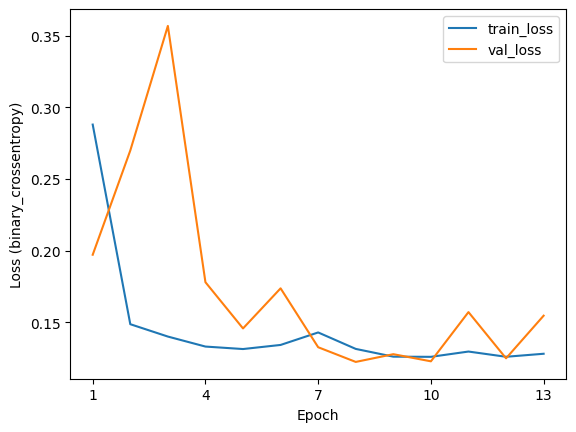

In [12]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = np.arange(1, len(loss) + 1)

plt.plot(epochs, loss, label='train_loss')
plt.plot(epochs, val_loss, label='val_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss (binary_crossentropy)')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))

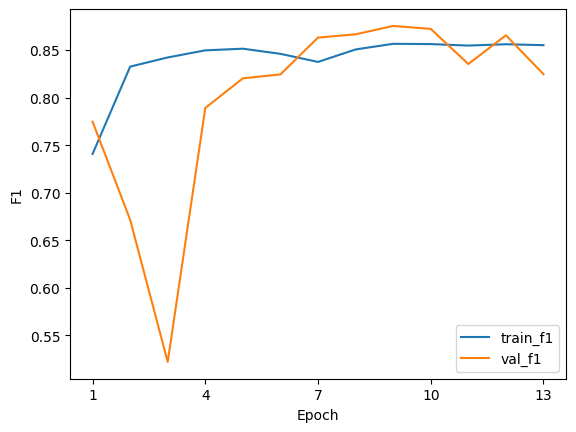

In [13]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
train_f1 = history.history['f1']
val_f1 = history.history['val_f1']

epochs = np.arange(1, len(train_f1) + 1)

plt.plot(epochs, train_f1, label='train_f1')
plt.plot(epochs, val_f1, label='val_f1')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('F1')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))